# 1. Setup and Dataset Processing

In [ ]:
from google.colab import drive
import os, sys
from pathlib import Path

drive.mount('/content/drive')

project_path = "/content/drive/MyDrive/Flinders_NN/research_synthetic_anomaly"
# project_path = "/content/drive/Othercomputers/My laptop/research_synthetic_anomaly"
# project_path = Path.cwd()

os.chdir(project_path)
sys.path.append(str(Path(project_path).parent))

Mounted at /content/drive


In [2]:
%pip install torchinfo
%pip install torch_geometric

import random

import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data_utils

from torchinfo import summary

random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

compute_device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {compute_device}')
print(f'torch version: {torch.__version__}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 35.3 MB/s eta 0:00:00
Using device: cuda
torch version: 2.10.0+cu128


## Build graph

Dummy KG built: 10 entities, 3 relations, 18 directed edges
Tensor shape: (10, 10, 3)  (N, N, R)
Density: 0.0667
Entity IDs: [100, 101, 102, 103, 104, 105, 106, 107, 108, 109]  (non-trivial, offset=100)
Relation IDs: [50, 51, 52]  (non-trivial, offset=50)
num_nodes=10, num_channels=3


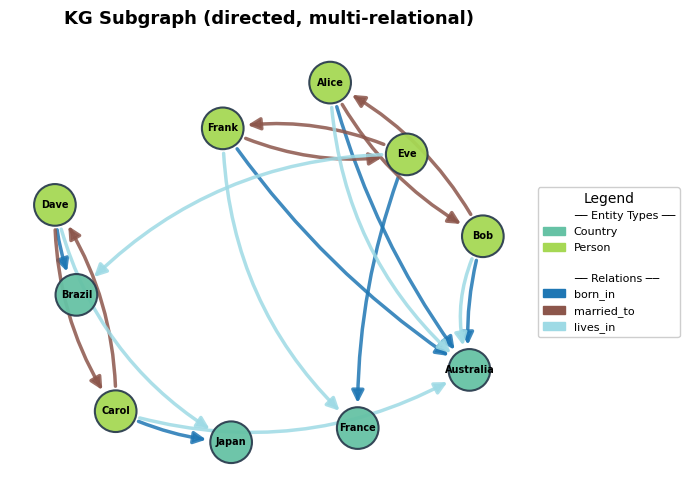

In [3]:
from build_graphs import build_dummy_kg, get_dummy_kg_metadata, visualise_kg_subgraph

# Same return signature as build_kg_subgraph()
adjacency_tensor, entity_id_to_row, relation_id_to_channel = build_dummy_kg()
relation_id_to_name, entity_id_to_name, node_labels, node_types = get_dummy_kg_metadata()

num_nodes    = adjacency_tensor.shape[0]   # N = 10
num_channels = adjacency_tensor.shape[2]   # R = 3

print(f'num_nodes={num_nodes}, num_channels={num_channels}')

# Visualise
visualise_kg_subgraph(
    adjacency_tensor,
    entity_id_to_row,
    relation_id_to_channel,
    relation_id_to_name,
    node_labels=node_labels,
    node_types=node_types,
    figsize=(7, 5),
)


# 2. Build Dataset



In [ ]:
# =============================================================================
# PATH D-HYBRID DATASET (triple-level pairs)
# =============================================================================
# Pix2Pix-style paired training data, but at the TRIPLE level:
# each pair is (clean_triple_indices, corrupted_triple_indices).
# Built by diffing TRIC-corrupted (R, N, N) tensors against their clean version
# and pairing the removed-edge / added-edge cells.

import functools
from corruption_strategies import apply_tric_corruption
from dataset_builders import build_kg_paired_dataset

# Hyperparameters
num_corruptions    = 2
num_training_pairs = 4000
dataset_rng        = np.random.default_rng(random_seed)

# Corruption strategy — change_relation only at first (TRIC type 3).
# To support multi-op later, change op_weights here.
tric_fn = functools.partial(
    apply_tric_corruption,
    node_types=node_types,
    op_weights={'change_relation': 1},
)

# Build (B, R, N, N) graph pairs (existing utility, reused)
clean_pairs, corrupted_pairs, _permutations = build_kg_paired_dataset(
    adjacency_tensor, num_training_pairs, num_corruptions, dataset_rng,
    corruption_fn=tric_fn,
)


def extract_triple_pairs_from_graph(clean_rxnxn, corrupted_rxnxn):
    """Given a (clean, corrupted) graph pair in [-1, 1], find triple-level
    (clean_triple, corrupted_triple) correspondences.

    For change_relation: a removed edge (i, r_old, j) and an added edge
    (i, r_new, j) at the same (i, j) form one triple pair.

    Returns: list of ((c_h, c_r, c_t), (t_h, t_r, t_t)) index tuples.
    """
    clean_bin = (clean_rxnxn > 0.0)
    corr_bin  = (corrupted_rxnxn > 0.0)

    removed = clean_bin & ~corr_bin
    added   = ~clean_bin & corr_bin

    rem_r, rem_i, rem_j = np.where(removed)
    add_r, add_i, add_j = np.where(added)

    added_lookup = {}
    for ar, ai, aj in zip(add_r, add_i, add_j):
        added_lookup.setdefault((int(ai), int(aj)), []).append(int(ar))

    pairs = []
    used_adds = set()
    for rr, ri, rj in zip(rem_r, rem_i, rem_j):
        key = (int(ri), int(rj))
        cands = [r for r in added_lookup.get(key, []) if (int(ri), int(rj), r) not in used_adds]
        if not cands:
            continue
        new_r = cands[0]
        used_adds.add((int(ri), int(rj), new_r))
        pairs.append((
            (int(ri), int(rr), int(rj)),
            (int(ri), new_r,    int(rj)),
        ))
    return pairs


all_triple_pairs = []
for i in range(num_training_pairs):
    clean_g = clean_pairs[i].numpy()       # (R, N, N) in [-1, 1]
    corr_g  = corrupted_pairs[i].numpy()
    all_triple_pairs.extend(extract_triple_pairs_from_graph(clean_g, corr_g))

# Pack into a single (M, 6) long tensor: [c_h, c_r, c_t, t_h, t_r, t_t]
triple_pairs_tensor = torch.tensor(
    [[c[0], c[1], c[2], t[0], t[1], t[2]] for c, t in all_triple_pairs],
    dtype=torch.long,
)

print(f'Graph pairs built:           {num_training_pairs}')
print(f'Triple pairs extracted:      {len(all_triple_pairs)}')
print(f'Avg triple pairs per graph:  {len(all_triple_pairs) / max(num_training_pairs, 1):.2f}  '
      f'(expected approx num_corruptions={num_corruptions})')
print(f'triple_pairs_tensor shape:   {tuple(triple_pairs_tensor.shape)}  (M, 6)')

# Sanity: every pair should preserve (h, t) and change r (pure change_relation)
chk = triple_pairs_tensor.numpy()
same_h = (chk[:, 0] == chk[:, 3]).mean()
same_t = (chk[:, 2] == chk[:, 5]).mean()
diff_r = (chk[:, 1] != chk[:, 4]).mean()
print(f'change_relation sanity: same_h={same_h:.3f}, same_t={same_t:.3f}, diff_r={diff_r:.3f}  '
      f'(all should be 1.0)')


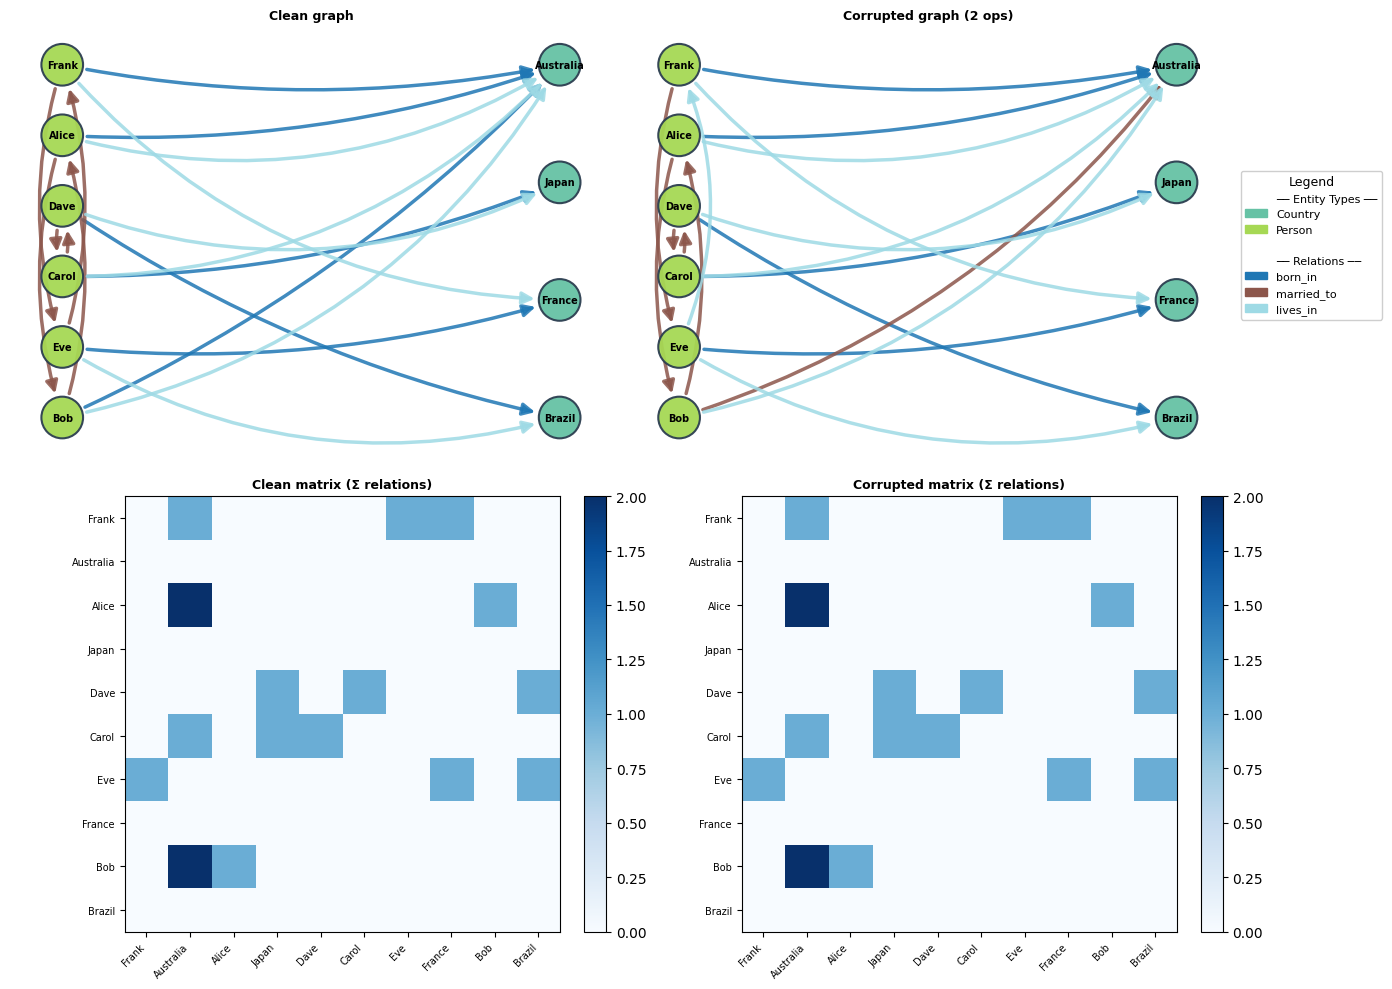

  Channel 0 (born_in): 6 clean → 5 corrupted edges
  Channel 1 (married_to): 6 clean → 6 corrupted edges
  Channel 2 (lives_in): 6 clean → 7 corrupted edges


In [ ]:
from visualisation import plot_dataset_sample

example_idx = 0
clean_cf = clean_pairs[example_idx]   # (R, N, N) in [-1, 1]
corr_cf  = corrupted_pairs[example_idx]

# Convert to (N, N, R) float in [0, 1] — format expected by the visualisation package
clean_nxnxr = ((clean_cf + 1.0) / 2.0).numpy().transpose(1, 2, 0)
corr_nxnxr  = ((corr_cf  + 1.0) / 2.0).numpy().transpose(1, 2, 0)

# Recover permutation for this sample: perm[k] = original node at row k after shuffle
# int() is required because perm elements are tensor scalars, not plain Python ints
perm = _permutations[example_idx]
permuted_labels = {k: node_labels[int(perm[k])] for k in range(num_nodes)}
permuted_types  = {k: node_types[int(perm[k])]  for k in range(num_nodes)}

# Relation names ordered by channel index
relation_names = [relation_id_to_name[rid]
                  for rid in sorted(relation_id_to_channel, key=relation_id_to_channel.get)]

plot_dataset_sample(
    clean_nxnxr, corr_nxnxr,
    permuted_labels, permuted_types,
    relation_names, num_corruptions=num_corruptions,
)

# Per-channel edge counts
for r in range(num_channels):
    clean_r = int(((clean_cf[r] + 1.0) / 2.0).sum())
    corr_r  = int(((corr_cf[r]  + 1.0) / 2.0).sum())
    print(f'  Channel {r} ({relation_names[r]}): {clean_r} clean → {corr_r} corrupted edges')


## Build dataloader

In [ ]:
# =============================================================================
# DATALOADER (over triple pairs)
# =============================================================================
# Each batch item is two long tensors of shape (3,): (h, r, t) indices for
# clean and target. Embeddings are looked up inside the training loop.

clean_triples_idx     = triple_pairs_tensor[:, :3]
corrupted_triples_idx = triple_pairs_tensor[:, 3:]

triple_pair_dataset = data_utils.TensorDataset(clean_triples_idx, corrupted_triples_idx)

training_batch_size = 64
paired_dataloader = data_utils.DataLoader(
    triple_pair_dataset, batch_size=training_batch_size, shuffle=True, drop_last=True,
)

print(f'Triple-pair dataset:    {len(triple_pair_dataset)} pairs')
print(f'Batches per epoch:      {len(paired_dataloader)}')
print(f'Clean triple idx shape: {tuple(clean_triples_idx.shape)}  (M, 3)')
print(f'Sample clean triple [0]:    {tuple(clean_triples_idx[0].tolist())}  (h, r, t)')
print(f'Sample target triple [0]:   {tuple(corrupted_triples_idx[0].tolist())}  (h, r, t)')


# 3. Path D-Hybrid Architecture (Dai data + Pix2Pix training)

**Generator -> clean triple -> corrupted triple (h', r', t').** Triple embeddings
`[E[h]; R[r]; E[t]]` go through Dai 2020's structural channel (1x1 Conv2d +
multi-head self-attention), the latent `z` is injected at the bottleneck
(Pix2Pix-style conditional translation), and three independent softmax heads
(extending Dai 2024's single softmax) produce categorical distributions over
the entity and relation vocabularies. Gumbel-Softmax keeps the categorical
sampling differentiable end-to-end.

**Discriminator -> (clean_triple_emb, candidate_triple_emb) -> real/fake.** Small
MLP critic with spectral_norm on every linear layer; Pix2Pix-style conditional
input (both clean and candidate are concatenated).

**Structural innovation:** Dai's generator only predicts one entity (relation is
input). By extending to three softmax heads, the relation becomes an output too,
which unlocks `change_relation` corruption (the user's primary example:
`Ann lives_in Australia` -> `Ann married Australia`).


In [ ]:
# =============================================================================
# PATH D-HYBRID ARCHITECTURE
# =============================================================================
# Data representation from Dai 2020 + 2024: learnable E, R embedding matrices;
# triple representation [h_emb; r_emb; t_emb]; Gumbel-Softmax categorical output.
# Training paradigm from Pix2Pix: paired (clean, corrupted) data; cGAN
# critic on (clean, candidate); CE reconstruction + adversarial loss.
#
# KEY STRUCTURAL CHANGE vs Dai: three softmax heads (one per triple position)
# instead of Dai's single softmax over entities. This unlocks change_relation
# because r is now an OUTPUT, not an input.

embedding_dim       = 100      # d in Dai 2020
latent_dim          = 8        # d_z in the spec - latent noise for diversity
encoder_base_depth  = 32       # C in Dai's 1x1 Conv encoder
encoder_n_layers    = 3        # number of conv layers in the structural encoder
encoder_n_heads     = 4        # heads for the multi-head self-attention
hidden_dim          = 128      # bottleneck width after self-attention
gumbel_tau_start    = 1.0      # Gumbel-Softmax temperature - training start
gumbel_tau_end      = 0.5      # temperature at end of warm phase
leaky_relu_negative_slope = 0.2


class EntityEmbedding(nn.Module):
    """Dai 2020 entity embedding lookup. Learnable, end-to-end trainable."""
    def __init__(self, num_entities, d):
        super().__init__()
        self.embed = nn.Embedding(num_entities, d)
        nn.init.normal_(self.embed.weight, mean=0.0, std=1.0 / (d ** 0.5))
    def forward(self, idx):
        return self.embed(idx)
    def lookup_weight(self):
        return self.embed.weight   # (|E|, d)


class RelationEmbedding(nn.Module):
    """Dai 2020 relation embedding lookup."""
    def __init__(self, num_relations, k):
        super().__init__()
        self.embed = nn.Embedding(num_relations, k)
        nn.init.normal_(self.embed.weight, mean=0.0, std=1.0 / (k ** 0.5))
    def forward(self, idx):
        return self.embed(idx)
    def lookup_weight(self):
        return self.embed.weight   # (|R|, k)


def gumbel_softmax_sample(logits, tau=1.0, hard=False, eps=1e-10):
    """Gumbel-Softmax (Dai 2024) - differentiable categorical sample."""
    u = torch.rand_like(logits).clamp_(eps, 1.0 - eps)
    gumbel = -torch.log(-torch.log(u))
    y = (logits + gumbel) / tau
    soft = torch.softmax(y, dim=-1)
    if hard:
        idx = soft.argmax(dim=-1, keepdim=True)
        hard_one = torch.zeros_like(soft).scatter_(-1, idx, 1.0)
        soft = (hard_one - soft).detach() + soft
    return soft


class TripleGenerator(nn.Module):
    """Path D-Hybrid generator.

      Encoder:  Dai 2020's structural channel - 1x1 Conv2d + multi-head
                self-attention on the (1, 3, d) "image" view of the triple.
      Bottleneck: concat latent z, project to hidden_dim (Pix2Pix-style
                  conditional translation + A2 latent diversity).
      Heads:    three independent MLPs producing logits over entity (h, t)
                or relation (r) vocabularies. Gumbel-Softmax for differentiable
                categorical sampling.

    Output is a dict with logits, soft samples, and a re-embedded (B, 3, d)
    candidate suitable for the discriminator.
    """
    def __init__(self, num_entities, num_relations, d, d_z,
                 enc_base=32, enc_layers=3, n_heads=4, hidden=128):
        super().__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.d = d
        self.d_z = d_z

        # 1x1 Conv2d stack on (B, 1, 3, d)
        conv_layers = []
        in_c, out_c = 1, enc_base
        for _ in range(enc_layers):
            conv_layers.append(nn.Conv2d(in_c, out_c, kernel_size=(1, 1)))
            conv_layers.append(nn.LeakyReLU(leaky_relu_negative_slope, inplace=True))
            in_c, out_c = out_c, out_c * 2
        self.encoder_conv = nn.Sequential(*conv_layers)
        encoder_final_c = in_c

        # Project per-position features into a common hidden dim
        self.token_proj = nn.Linear(encoder_final_c * d, hidden)
        self.self_attn = nn.MultiheadAttention(
            embed_dim=hidden, num_heads=n_heads, batch_first=True,
        )
        self.attn_norm = nn.LayerNorm(hidden)

        # Bottleneck with latent injection
        self.bottleneck_proj = nn.Linear(hidden * 3 + d_z, hidden)

        # Three output heads
        self.head_h = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_entities),
        )
        self.head_r = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_relations),
        )
        self.head_t = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, num_entities),
        )

    def forward(self, clean_triple_emb, z, tau=1.0, return_soft=True):
        B = clean_triple_emb.shape[0]
        x = clean_triple_emb.unsqueeze(1)        # (B, 1, 3, d)
        x = self.encoder_conv(x)                 # (B, C_final, 3, d)
        x = x.permute(0, 2, 1, 3).contiguous().view(B, 3, -1)
        tokens = self.token_proj(x)              # (B, 3, hidden)
        attn_out, _ = self.self_attn(tokens, tokens, tokens)
        tokens = self.attn_norm(tokens + attn_out)
        triple_vec = tokens.flatten(1)           # (B, 3 * hidden)
        bn_in = torch.cat([triple_vec, z], dim=1)
        h_state = self.bottleneck_proj(bn_in)    # (B, hidden)

        h_logits = self.head_h(h_state)
        r_logits = self.head_r(h_state)
        t_logits = self.head_t(h_state)
        out = {'h_logits': h_logits, 'r_logits': r_logits, 't_logits': t_logits}
        if return_soft:
            out['h_soft'] = gumbel_softmax_sample(h_logits, tau=tau)
            out['r_soft'] = gumbel_softmax_sample(r_logits, tau=tau)
            out['t_soft'] = gumbel_softmax_sample(t_logits, tau=tau)
        return out


class TripleDiscriminator(nn.Module):
    """Pix2Pix-style cGAN critic on (clean, candidate) triple embeddings.

    Small MLP body with spectral_norm on every Linear layer (preserves the
    project's Lipschitz-enforcement stabilisation).
    """
    def __init__(self, d, hidden=256):
        super().__init__()
        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(6 * d, hidden)),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),
            nn.utils.spectral_norm(nn.Linear(hidden, hidden // 2)),
            nn.LeakyReLU(leaky_relu_negative_slope, inplace=True),
            nn.utils.spectral_norm(nn.Linear(hidden // 2, 1)),
        )

    def forward(self, clean_triple_emb, candidate_triple_emb):
        x = torch.cat([clean_triple_emb.flatten(1), candidate_triple_emb.flatten(1)], dim=1)
        return self.net(x)


def re_embed_soft(h_soft, r_soft, t_soft, E_weight, R_weight):
    """Convert Gumbel-Softmax soft samples back to (B, 3, d) triple embedding."""
    h_emb = h_soft @ E_weight
    r_emb = r_soft @ R_weight
    t_emb = t_soft @ E_weight
    return torch.stack([h_emb, r_emb, t_emb], dim=1)


# =============================================================================
# INSTANTIATE
# =============================================================================
entity_embedding   = EntityEmbedding(num_nodes, embedding_dim).to(compute_device)
relation_embedding = RelationEmbedding(num_channels, embedding_dim).to(compute_device)

generator_model = TripleGenerator(
    num_entities=num_nodes,
    num_relations=num_channels,
    d=embedding_dim,
    d_z=latent_dim,
    enc_base=encoder_base_depth,
    enc_layers=encoder_n_layers,
    n_heads=encoder_n_heads,
    hidden=hidden_dim,
).to(compute_device)

discriminator_model = TripleDiscriminator(d=embedding_dim, hidden=256).to(compute_device)

print('TripleGenerator:')
print(generator_model)
print(f'\nGenerator parameters:    {sum(p.numel() for p in generator_model.parameters()):,}')
print('\nTripleDiscriminator (spectral_norm on every Linear):')
print(discriminator_model)
print(f'\nDiscriminator parameters: {sum(p.numel() for p in discriminator_model.parameters()):,}')
print(f'\nEntityEmbedding parameters:   {sum(p.numel() for p in entity_embedding.parameters()):,}  '
      f'(|E|={num_nodes} x d={embedding_dim})')
print(f'RelationEmbedding parameters: {sum(p.numel() for p in relation_embedding.parameters()):,}  '
      f'(|R|={num_channels} x d={embedding_dim})')


In [ ]:
# Shape sanity - one forward pass through G and D on a tiny batch.
with torch.no_grad():
    _clean_idx  = clean_triples_idx[:4].to(compute_device)
    _target_idx = corrupted_triples_idx[:4].to(compute_device)

    _h_emb = entity_embedding(_clean_idx[:, 0])
    _r_emb = relation_embedding(_clean_idx[:, 1])
    _t_emb = entity_embedding(_clean_idx[:, 2])
    _clean_triple_emb = torch.stack([_h_emb, _r_emb, _t_emb], dim=1)   # (4, 3, d)

    _z = torch.randn(4, latent_dim, device=compute_device)
    _out = generator_model(_clean_triple_emb, _z, tau=gumbel_tau_start, return_soft=True)

    _cand_emb = re_embed_soft(
        _out['h_soft'], _out['r_soft'], _out['t_soft'],
        entity_embedding.lookup_weight(), relation_embedding.lookup_weight(),
    )
    _d_real = discriminator_model(_clean_triple_emb, _clean_triple_emb)
    _d_fake = discriminator_model(_clean_triple_emb, _cand_emb)

print(f'Clean triple emb shape: {tuple(_clean_triple_emb.shape)}  '
      f'(expected (4, 3, {embedding_dim}))')
print(f'h_logits shape:         {tuple(_out["h_logits"].shape)}  '
      f'(expected (4, {num_nodes}))')
print(f'r_logits shape:         {tuple(_out["r_logits"].shape)}  '
      f'(expected (4, {num_channels}))')
print(f't_logits shape:         {tuple(_out["t_logits"].shape)}  '
      f'(expected (4, {num_nodes}))')
print(f'Candidate triple emb:   {tuple(_cand_emb.shape)}')
print(f'D output shape:         {tuple(_d_real.shape)}  (expected (4, 1))')
print(f'D logit (clean,clean):  {_d_real.mean().item():.3f}')
print(f'D logit (clean,fake):   {_d_fake.mean().item():.3f}')


# 4. Training Loop (Pix2Pix paradigm + CE reconstruction)

Alternating G/D updates with paired (clean, corrupted) triples from TRIC.
Reconstruction loss is **cross-entropy on three softmax heads** (the categorical
analogue of Pix2Pix's L1 for image translation). cGAN adversarial loss provides
the adversarial sharpening. Mode-seeking diversity regulariser (Mao et al. CVPR
2019) prevents the latent `z` from being ignored.


In [ ]:
# =============================================================================
# PATH D-HYBRID TRAINING LOOP
# =============================================================================
# Pix2Pix-style alternating G/D updates. Replaces Pix2Pix's L1 reconstruction
# with cross-entropy on three softmax heads (the categorical analogue).
# Mode-seeking diversity regulariser (Mao et al. CVPR 2019) prevents z-collapse.

total_epochs        = 400
learning_rate       = 1e-4
adam_beta1          = 0.5
adam_beta2          = 0.999
lambda_recon        = 20.0
lambda_adv          = 1.0
lambda_div          = 0.5
REAL_LABEL_VALUE    = 0.9
FAKE_LABEL_VALUE    = 0.0

# Instance noise on D inputs (project's known-good stabiliser, kept)
instance_noise_std_start = 0.1
instance_noise_std_end   = 0.01

bce_logits_loss = nn.BCEWithLogitsLoss().to(compute_device)
ce_loss         = nn.CrossEntropyLoss().to(compute_device)


def add_instance_noise_emb(clean_emb, candidate_emb, std):
    if std <= 0:
        return clean_emb, candidate_emb
    return (clean_emb     + torch.randn_like(clean_emb)     * std,
            candidate_emb + torch.randn_like(candidate_emb) * std)


def mode_seeking_loss(cand_1, cand_2, z_1, z_2, eps=1e-6):
    out_diff = (cand_1 - cand_2).abs().mean()
    z_diff   = (z_1 - z_2).abs().mean()
    return -out_diff / (z_diff + eps)


def build_triple_emb(idx_tuple, e_module, r_module):
    """Look up (h, r, t) embeddings and stack to (B, 3, d). Caller controls
    gradient context (use under no_grad for D-step; outside for G-step)."""
    return torch.stack([
        e_module(idx_tuple[:, 0]),
        r_module(idx_tuple[:, 1]),
        e_module(idx_tuple[:, 2]),
    ], dim=1)


# G optimiser also updates the embedding matrices
g_params = (list(generator_model.parameters())
            + list(entity_embedding.parameters())
            + list(relation_embedding.parameters()))
generator_optimizer = optim.Adam(g_params, lr=learning_rate,
                                 betas=(adam_beta1, adam_beta2))
discriminator_optimizer = optim.Adam(
    discriminator_model.parameters(), lr=learning_rate * 0.25,
    betas=(adam_beta1, adam_beta2),
)

generator_adv_loss_history     = []
generator_recon_loss_history   = []
generator_div_loss_history     = []
generator_total_loss_history   = []
discriminator_loss_history     = []
discriminator_output_on_real   = []
discriminator_output_on_fake_before_g_update = []
discriminator_output_on_fake_after_g_update  = []
instance_noise_std_history     = []
gumbel_tau_history             = []

print(f'Path D-Hybrid training: {total_epochs} epochs, {len(paired_dataloader)} batches each')
print(f'lambda_recon={lambda_recon}, lambda_adv={lambda_adv}, lambda_div={lambda_div}')
print(f'G lr={learning_rate:.1e}, D lr={learning_rate * 0.25:.1e}')
print(f'Instance noise: std {instance_noise_std_start} -> {instance_noise_std_end} (linear decay)')
print(f'Gumbel tau: {gumbel_tau_start} -> {gumbel_tau_end} (anneal over first 50% of training)')
print('-' * 70)

generator_model.train()
discriminator_model.train()

for epoch_index in range(total_epochs):
    epoch_d_loss_sum, epoch_d_loss_count = 0.0, 0

    if total_epochs > 1:
        epoch_progress = epoch_index / (total_epochs - 1)
    else:
        epoch_progress = 0.0
    current_noise_std = (instance_noise_std_start * (1 - epoch_progress)
                         + instance_noise_std_end * epoch_progress)
    instance_noise_std_history.append(current_noise_std)

    anneal_progress = min(1.0, epoch_index / max(1, total_epochs // 2))
    current_tau = gumbel_tau_start * (1 - anneal_progress) + gumbel_tau_end * anneal_progress
    gumbel_tau_history.append(current_tau)

    for batch_index, (clean_idx, target_idx) in enumerate(paired_dataloader):
        clean_idx  = clean_idx.to(compute_device)
        target_idx = target_idx.to(compute_device)
        B = clean_idx.size(0)

        real_label_tensor = torch.full((B, 1), REAL_LABEL_VALUE,
                                       device=compute_device, dtype=torch.float)
        fake_label_tensor = torch.full((B, 1), FAKE_LABEL_VALUE,
                                       device=compute_device, dtype=torch.float)

        # =====================================================================
        # Step 1: Update Discriminator
        # ---------------------------------------------------------------------
        # Build embeddings UNDER no_grad: the D-step only updates D's params,
        # not the embedding matrices. Building under no_grad detaches the
        # autograd graph so backward() doesn't try to traverse through E, R.
        # =====================================================================
        discriminator_model.zero_grad()

        with torch.no_grad():
            clean_emb_d  = build_triple_emb(clean_idx,  entity_embedding, relation_embedding)
            target_emb_d = build_triple_emb(target_idx, entity_embedding, relation_embedding)

            z_for_d = torch.randn(B, latent_dim, device=compute_device)
            g_out_d = generator_model(clean_emb_d, z_for_d, tau=current_tau,
                                       return_soft=True)
            cand_emb_d = re_embed_soft(
                g_out_d['h_soft'], g_out_d['r_soft'], g_out_d['t_soft'],
                entity_embedding.lookup_weight(),
                relation_embedding.lookup_weight(),
            )

        # D forward on real pair
        clean_n_r, target_n_r = add_instance_noise_emb(
            clean_emb_d, target_emb_d, current_noise_std)
        d_real      = discriminator_model(clean_n_r, target_n_r)
        d_loss_real = bce_logits_loss(d_real, real_label_tensor)

        # D forward on fake pair
        clean_n_f, cand_n_f = add_instance_noise_emb(
            clean_emb_d, cand_emb_d, current_noise_std)
        d_fake      = discriminator_model(clean_n_f, cand_n_f)
        d_loss_fake = bce_logits_loss(d_fake, fake_label_tensor)

        # Single backward on the combined D loss - avoids double-backward
        total_d_loss = d_loss_real + d_loss_fake
        total_d_loss.backward()

        mean_d_real_step      = torch.sigmoid(d_real).mean().item()
        mean_d_fake_before_g  = torch.sigmoid(d_fake).mean().item()

        torch.nn.utils.clip_grad_norm_(discriminator_model.parameters(), max_norm=5.0)
        discriminator_optimizer.step()
        epoch_d_loss_sum   += total_d_loss.item()
        epoch_d_loss_count += 1

        # =====================================================================
        # Step 2: Update Generator + Embeddings
        # ---------------------------------------------------------------------
        # Rebuild clean_emb WITH gradient (Dai's E, R are trainable here).
        # =====================================================================
        generator_optimizer.zero_grad()

        clean_emb_g = build_triple_emb(clean_idx, entity_embedding, relation_embedding)

        z_1 = torch.randn(B, latent_dim, device=compute_device)
        z_2 = torch.randn(B, latent_dim, device=compute_device)

        g_out_1 = generator_model(clean_emb_g, z_1, tau=current_tau, return_soft=True)
        g_out_2 = generator_model(clean_emb_g, z_2, tau=current_tau, return_soft=True)

        cand_emb_1 = re_embed_soft(
            g_out_1['h_soft'], g_out_1['r_soft'], g_out_1['t_soft'],
            entity_embedding.lookup_weight(), relation_embedding.lookup_weight(),
        )
        cand_emb_2 = re_embed_soft(
            g_out_2['h_soft'], g_out_2['r_soft'], g_out_2['t_soft'],
            entity_embedding.lookup_weight(), relation_embedding.lookup_weight(),
        )

        # Reconstruction: CE on three heads (z_1 branch)
        l_recon_h = ce_loss(g_out_1['h_logits'], target_idx[:, 0])
        l_recon_r = ce_loss(g_out_1['r_logits'], target_idx[:, 1])
        l_recon_t = ce_loss(g_out_1['t_logits'], target_idx[:, 2])
        l_recon = l_recon_h + l_recon_r + l_recon_t

        # Adversarial (z_1 branch)
        clean_n_g, cand_n_g = add_instance_noise_emb(
            clean_emb_g, cand_emb_1, current_noise_std)
        d_fake_for_g = discriminator_model(clean_n_g, cand_n_g)
        l_adv = bce_logits_loss(d_fake_for_g, real_label_tensor)
        mean_d_fake_after_g = torch.sigmoid(d_fake_for_g).mean().item()

        # Mode-seeking diversity
        l_div = mode_seeking_loss(cand_emb_1, cand_emb_2, z_1, z_2)

        total_g_loss = (lambda_recon * l_recon
                        + lambda_adv  * l_adv
                        + lambda_div  * l_div)
        total_g_loss.backward()
        torch.nn.utils.clip_grad_norm_(g_params, max_norm=5.0)
        generator_optimizer.step()

        generator_adv_loss_history.append(l_adv.item())
        generator_recon_loss_history.append(l_recon.item())
        generator_div_loss_history.append(l_div.item())
        generator_total_loss_history.append(total_g_loss.item())
        discriminator_loss_history.append(total_d_loss.item())
        discriminator_output_on_real.append(mean_d_real_step)
        discriminator_output_on_fake_before_g_update.append(mean_d_fake_before_g)
        discriminator_output_on_fake_after_g_update.append(mean_d_fake_after_g)

    epoch_d_loss_avg = epoch_d_loss_sum / max(epoch_d_loss_count, 1)
    if (epoch_index + 1) % 15 == 0 or epoch_index == 0:
        print(f'[{epoch_index + 1:3d}/{total_epochs}]  '
              f'L_D: {epoch_d_loss_avg:.4f}  '
              f'L_G_adv: {l_adv.item():.4f}  '
              f'L_G_recon: {l_recon.item():.4f}  '
              f'L_G_div: {l_div.item():+.4f}  '
              f'D(real): {mean_d_real_step:.3f}  '
              f'D(fake): {mean_d_fake_before_g:.3f}/{mean_d_fake_after_g:.3f}  '
              f'noise: {current_noise_std:.3f}  tau: {current_tau:.2f}')

print('-' * 70)
print('Training Complete!')


In [ ]:
# =============================================================================
# TRAINING LOG EXPLANATION (Path D-Hybrid)
# =============================================================================
#
# Each printed line has this format:
#
# [epoch/total]  L_D  L_G_adv  L_G_recon  L_G_div  D(real)  D(fake): X/Y  noise  tau
#
# -----------------------------------------------------------------------------
#
# L_D
#   Discriminator BCE loss (sum of real-pair and fake-pair terms).
#   Ideal: stable around 0.3 - 0.7 (D and G in competition).
#
# L_G_adv
#   Adversarial loss for the generator (how much D detected its output as fake).
#   Under heavy lambda_recon, this is a regulariser, not the primary signal.
#
# L_G_recon
#   Reconstruction loss: CE(h_logits, target_h) + CE(r) + CE(t).
#   This is the bulk of the signal. Should trend downward to 0 if G is
#   learning to imitate TRIC's corruption.
#
# L_G_div
#   Mode-seeking diversity regulariser (Mao et al. 2019).
#   Negative = good (distinct latents produce distinct outputs).
#   Approaching zero = posterior collapse (G is ignoring z).
#
# D(real)
#   Probability D assigns to a real (clean, target) pair.
#   Ideal: 0.7 - 0.9.
#
# D(fake): X/Y
#   X = D(clean, fake) BEFORE this batch's G update.
#   Y = D(clean, fake) AFTER  this batch's G update.
#   Ideal: X around 0.3 - 0.6 (D and G competing).
#
# noise
#   Current instance-noise std applied to D inputs (linearly decays).
#
# tau
#   Current Gumbel-Softmax temperature (anneals from 1.0 to 0.5 over first
#   half of training, then constant).
#
# -----------------------------------------------------------------------------
# HEALTHY TRAINING looks like:
#   L_D        : stable around 0.3 - 0.7
#   L_G_adv    : moderate, may rise late (D winning side-game is fine under
#                heavy lambda_recon - Pix2Pix s6.3 regime)
#   L_G_recon  : steadily decreasing
#   L_G_div    : negative, stable (z is informative)
#   D(real)    : around 0.7 - 0.9
#   D(fake)    : around 0.3 - 0.6
#
# UNHEALTHY patterns:
#   L_D collapsed to ~0      : D dominates; check spectral_norm + instance noise
#   L_G_recon plateaus high  : G not learning the TRIC pattern
#   L_G_div approaches 0     : posterior collapse; raise lambda_div or d_z
# =============================================================================


# 5. Training Diagnostics

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].set_title('Adversarial Losses')
axes[0].plot(generator_adv_loss_history, label='G adv',  alpha=0.7)
axes[0].plot(discriminator_loss_history, label='D total', alpha=0.7)
axes[0].set_xlabel('Iterations'); axes[0].set_ylabel('Loss'); axes[0].legend()

axes[1].set_title('G Reconstruction (CE on 3 heads)\nShould trend down')
axes[1].plot(generator_recon_loss_history, color='C2', alpha=0.7)
axes[1].set_xlabel('Iterations'); axes[1].set_ylabel('CE(h)+CE(r)+CE(t)')

axes[2].set_title('Diversity Regulariser\n(more negative = more diverse)')
axes[2].plot(generator_div_loss_history, color='C4', alpha=0.7)
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_xlabel('Iterations'); axes[2].set_ylabel('-mean|d_cand|/(mean|d_z|+eps)')

axes[3].set_title('Discriminator Outputs on Pairs')
axes[3].plot(discriminator_output_on_real,                 label='D(clean, real)', alpha=0.7)
axes[3].plot(discriminator_output_on_fake_before_g_update, label='D(clean, fake)', alpha=0.7)
axes[3].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Equilibrium')
axes[3].set_xlabel('Iterations'); axes[3].set_ylabel('D output'); axes[3].set_ylim(-0.05, 1.05)
axes[3].legend()

plt.tight_layout(); plt.show()


# 6. Generate Corrupted KG from Clean Input

Two-stage inference for Path D-Hybrid:

  - **Stage A**: stochastically select which triples to corrupt (rule-based,
    mirroring TRIC's selection of `num_corruptions` triples per graph).
  - **Stage B**: for each selected triple, sample a latent `z` and forward G
    to get a corrupted triple via argmax of the three softmax heads.

Repeating this whole pipeline K times yields a population of K distinct
corrupted KGs. Diversity comes from both Stage-A randomness (which triples)
and Stage-B randomness (latent z + Gumbel-Softmax sampling).


In [ ]:
# =============================================================================
# PATH D-HYBRID INFERENCE - Stage A setup
# =============================================================================
# Stage A (rule-based): pick which triples to corrupt.
# Stage B (G):          for each picked triple, sample z and run G.

clean_adjacency_tensor = adjacency_tensor   # (N, N, R) float32 in {0, 1}

# Extract all clean triples from the adjacency tensor (h, r, t) where adj[h, t, r] = 1
clean_triples_in_kg = []
for r in range(num_channels):
    rows, cols = np.where(clean_adjacency_tensor[:, :, r] > 0.5)
    for h, t in zip(rows, cols):
        if h != t:
            clean_triples_in_kg.append((int(h), r, int(t)))

print(f'Inference graph: {clean_adjacency_tensor.shape}  (N, N, R)')
print(f'Total triples:   {len(clean_triples_in_kg)}')
for r in range(num_channels):
    rel_id = list(relation_id_to_channel.keys())[r]
    rel_name = relation_id_to_name.get(rel_id, f'rel_{r}')
    count = sum(1 for tri in clean_triples_in_kg if tri[1] == r)
    print(f'  Channel {r} ({rel_name}): {count} triples')


In [ ]:
# Two-stage inference: K diverse corrupted KGs from one clean KG.
generator_model.eval()
discriminator_model.eval()

K_samples       = 20
inference_rng   = np.random.default_rng(7777)
inference_tau   = 0.5          # post-training Gumbel temperature

corrupted_kgs = []   # list of K corrupted KGs, each = list of (h, r, t) tuples

with torch.no_grad():
    for k in range(K_samples):
        # Stage A: stochastic selection of triples to corrupt
        n_total   = len(clean_triples_in_kg)
        n_corrupt = min(num_corruptions, n_total)
        selected  = set(int(i) for i in
                        inference_rng.choice(n_total, size=n_corrupt, replace=False))

        # Stage B: forward G per selected triple
        out_kg = []
        for i, (h, r, t) in enumerate(clean_triples_in_kg):
            if i not in selected:
                out_kg.append((h, r, t))
                continue
            h_emb = entity_embedding(torch.tensor([h], device=compute_device))
            r_emb = relation_embedding(torch.tensor([r], device=compute_device))
            t_emb = entity_embedding(torch.tensor([t], device=compute_device))
            clean_triple_emb = torch.stack([h_emb, r_emb, t_emb], dim=1)   # (1, 3, d)
            z = torch.randn(1, latent_dim, device=compute_device)
            g_out = generator_model(clean_triple_emb, z, tau=inference_tau,
                                    return_soft=False)
            h_new = int(g_out['h_logits'].argmax(dim=-1).item())
            r_new = int(g_out['r_logits'].argmax(dim=-1).item())
            t_new = int(g_out['t_logits'].argmax(dim=-1).item())
            out_kg.append((h_new, r_new, t_new))
        corrupted_kgs.append(out_kg)

print(f'Drew K={K_samples} corrupted KGs (each with {n_corrupt} corruptions out of {n_total} triples).')
print(f'Sample 0 triple count: {len(corrupted_kgs[0])}')


In [ ]:
def categorise_corruption(clean_kg, corrupted_kg):
    """Classify each changed triple. Returns dict of operation counts."""
    counts = dict(change_relation=0, swap_subject=0, swap_object=0,
                  multi_op=0, no_change=0)
    if len(corrupted_kg) != len(clean_kg):
        return counts
    for clean_tri, corr_tri in zip(clean_kg, corrupted_kg):
        if clean_tri == corr_tri:
            counts['no_change'] += 1
            continue
        h,  r,  t  = clean_tri
        h2, r2, t2 = corr_tri
        if h == h2 and t == t2 and r != r2:    counts['change_relation'] += 1
        elif r == r2 and t == t2 and h != h2:  counts['swap_subject']    += 1
        elif h == h2 and r == r2 and t != t2:  counts['swap_object']     += 1
        else:                                   counts['multi_op']       += 1
    return counts


# Per-sample table
print(f'{"Sample":<8} {"chg_rel":<10} {"swp_sub":<10} {"swp_obj":<10} {"multi":<10} {"identity":<10}')
print('-' * 60)
total_counts = dict(change_relation=0, swap_subject=0, swap_object=0,
                    multi_op=0, no_change=0)
distinct_outputs = set()
for k, corr_kg in enumerate(corrupted_kgs):
    c = categorise_corruption(clean_triples_in_kg, corr_kg)
    for key in total_counts:
        total_counts[key] += c[key]
    distinct_outputs.add(tuple(sorted(corr_kg)))
    if k < 5:
        print(f'{k:<8} {c["change_relation"]:<10} {c["swap_subject"]:<10} '
              f'{c["swap_object"]:<10} {c["multi_op"]:<10} {c["no_change"]:<10}')
print('-' * 60)
print(f'TOTAL    {total_counts["change_relation"]:<10} {total_counts["swap_subject"]:<10} '
      f'{total_counts["swap_object"]:<10} {total_counts["multi_op"]:<10} {total_counts["no_change"]:<10}')
print(f'\nDistinct corrupted KGs across K={K_samples}: {len(distinct_outputs)}')

# Detailed view of first 3 samples
print('\n=== Detailed view (first 3 samples) ===')
channel_to_rel = {r: list(relation_id_to_channel.keys())[r] for r in range(num_channels)}
for k in range(min(3, K_samples)):
    print(f'\n--- Sample {k} ---')
    corr_kg = corrupted_kgs[k]
    any_change = False
    for clean_tri, corr_tri in zip(clean_triples_in_kg, corr_kg):
        if clean_tri == corr_tri:
            continue
        any_change = True
        h,  r,  t  = clean_tri
        h2, r2, t2 = corr_tri
        clean_str = (f'{node_labels[h]} --'
                     f'{relation_id_to_name[channel_to_rel[r]]}--> '
                     f'{node_labels[t]}')
        corr_str  = (f'{node_labels[h2]} --'
                     f'{relation_id_to_name[channel_to_rel[r2]]}--> '
                     f'{node_labels[t2]}')
        if   h == h2 and t == t2 and r != r2:   op = '[change_relation]'
        elif r == r2 and t == t2 and h != h2:   op = '[swap_subject]'
        elif h == h2 and r == r2 and t != t2:   op = '[swap_object]'
        else:                                    op = '[multi_op]'
        print(f'  CHANGED:  {clean_str}  ==>  {corr_str}  {op}')
    if not any_change:
        print('  (no triples changed - identity sample)')


In [ ]:
import functools
from corruption_strategies import apply_tric_corruption
from visualisation import plot_gan_comparison


def kg_triples_to_nxnxr(kg_triples, n, r_count):
    """Convert list of (h, r, t) indices back to (N, N, R) float32 in {0, 1}."""
    adj = np.zeros((n, n, r_count), dtype=np.float32)
    for h, r, t in kg_triples:
        if h != t:
            adj[h, t, r] = 1.0
    return adj


# Reference rule corruption (same strategy as training)
rule_rng    = np.random.default_rng(999)
tric_ref_fn = functools.partial(apply_tric_corruption, node_types=node_types,
                                op_weights={'change_relation': 1})
rule_corrupted_nxnxr = tric_ref_fn(clean_adjacency_tensor, num_corruptions, rule_rng)

# GAN output: first sample, converted to (N, N, R)
gan_nxnxr = kg_triples_to_nxnxr(corrupted_kgs[0], num_nodes, num_channels)

relation_names = [relation_id_to_name[rid]
                  for rid in sorted(relation_id_to_channel, key=relation_id_to_channel.get)]

plot_gan_comparison(
    clean_adjacency_tensor, rule_corrupted_nxnxr, gan_nxnxr,
    node_labels, node_types,
    relation_names, num_corruptions=num_corruptions,
)


# 7. Validation: Does the GAN Match the Corruption Distribution?

A proof-of-concept Path D-Hybrid GAN should reproduce the *statistical
distribution* of the rule, not just one sample. We compare relation-shift
counts across many draws from the GAN vs many draws from the rule. The
operation-mix histogram further classifies each GAN-emitted corruption as
`change_relation`, `swap_subject`, `swap_object`, `multi_op`, or `no_change`.

When trained on TRIC `change_relation`-only data, the GAN should:
  - shift roughly `num_corruptions` edges per sample;
  - have a net edge delta near zero (change_relation conserves edge count);
  - emit `change_relation` for the vast majority of corruption events.


In [ ]:
import functools
from corruption_strategies import apply_tric_corruption

num_validation_samples = 200
rule_shifted_counts = []
gan_shifted_counts  = []
gan_net_delta       = []
gan_op_counts       = dict(change_relation=0, swap_subject=0, swap_object=0,
                           multi_op=0, no_change=0)

tric_val_fn    = functools.partial(apply_tric_corruption, node_types=node_types,
                                   op_weights={'change_relation': 1})
validation_rng = np.random.default_rng(12345)

generator_model.eval()

with torch.no_grad():
    for _ in range(num_validation_samples):
        # Rule corruption (same strategy as training)
        rule_corr = tric_val_fn(clean_adjacency_tensor, num_corruptions, validation_rng)
        rule_shifted_counts.append(int(((clean_adjacency_tensor - rule_corr) > 0.5).sum()))

        # GAN corruption: Stage A + Stage B (one validation sample)
        n_total   = len(clean_triples_in_kg)
        n_corrupt = min(num_corruptions, n_total)
        selected  = set(int(i) for i in
                        validation_rng.choice(n_total, size=n_corrupt, replace=False))
        out_kg = []
        for i, (h, r, t) in enumerate(clean_triples_in_kg):
            if i not in selected:
                out_kg.append((h, r, t))
                continue
            h_emb = entity_embedding(torch.tensor([h], device=compute_device))
            r_emb = relation_embedding(torch.tensor([r], device=compute_device))
            t_emb = entity_embedding(torch.tensor([t], device=compute_device))
            clean_triple_emb = torch.stack([h_emb, r_emb, t_emb], dim=1)
            z = torch.randn(1, latent_dim, device=compute_device)
            g_out = generator_model(clean_triple_emb, z, tau=0.5, return_soft=False)
            out_kg.append((
                int(g_out['h_logits'].argmax(dim=-1).item()),
                int(g_out['r_logits'].argmax(dim=-1).item()),
                int(g_out['t_logits'].argmax(dim=-1).item()),
            ))

        # Convert GAN output to (N, N, R) for comparison with rule output
        gan_nxnxr_val = np.zeros((num_nodes, num_nodes, num_channels), dtype=np.float32)
        for h, r, t in out_kg:
            if h != t:
                gan_nxnxr_val[h, t, r] = 1.0
        gan_shifted_counts.append(int(((clean_adjacency_tensor - gan_nxnxr_val) > 0.5).sum()))
        gan_net_delta.append(int(gan_nxnxr_val.sum()) - int(clean_adjacency_tensor.sum()))

        # Operation-mix accounting
        c = dict(change_relation=0, swap_subject=0, swap_object=0,
                 multi_op=0, no_change=0)
        for clean_tri, corr_tri in zip(clean_triples_in_kg, out_kg):
            if clean_tri == corr_tri:
                c['no_change'] += 1
                continue
            h,  r,  t  = clean_tri
            h2, r2, t2 = corr_tri
            if h == h2 and t == t2 and r != r2:   c['change_relation'] += 1
            elif r == r2 and t == t2 and h != h2: c['swap_subject']    += 1
            elif h == h2 and r == r2 and t != t2: c['swap_object']     += 1
            else:                                  c['multi_op']       += 1
        for key in gan_op_counts:
            gan_op_counts[key] += c[key]

rule_shifted_counts = np.array(rule_shifted_counts)
gan_shifted_counts  = np.array(gan_shifted_counts)
gan_net_delta       = np.array(gan_net_delta)

print(f'Over {num_validation_samples} samples (each Stage-A selects {num_corruptions} triples):')
print(f'  Rule - edges shifted channel: mean={rule_shifted_counts.mean():5.1f}, '
      f'std={rule_shifted_counts.std():.2f}  (expect ~{num_corruptions})')
print(f'  GAN  - edges shifted channel: mean={gan_shifted_counts.mean():5.1f},  '
      f'std={gan_shifted_counts.std():.2f}')
print(f'  GAN  - net edge delta:        mean={gan_net_delta.mean():+.2f}, '
      f'std={gan_net_delta.std():.2f}  (expect ~0 for change_relation)')
print()
print(f'GAN operation-mix across {num_validation_samples * num_corruptions} corruption events:')
for key, count in gan_op_counts.items():
    if key == 'no_change':
        continue   # Stage A excludes unselected triples; no_change here means G chose to keep
    print(f'  {key:<20s}: {count:5d}  '
          f'({100.0 * count / (num_validation_samples * num_corruptions):.1f}%)')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3))

bin_edges = np.arange(
    min(rule_shifted_counts.min(), gan_shifted_counts.min()) - 1,
    max(rule_shifted_counts.max(), gan_shifted_counts.max()) + 2
)

axes[0].hist(rule_shifted_counts, bins=bin_edges, alpha=0.6,
             label='Rule', color='C0', edgecolor='black')
axes[0].hist(gan_shifted_counts,  bins=bin_edges, alpha=0.6,
             label='GAN',  color='C3', edgecolor='black')
axes[0].set_xlabel('Edges that changed relation channel')
axes[0].set_ylabel('Sample count')
axes[0].set_title('Relation-shift distribution\nrule vs GAN (Path D-Hybrid)')
axes[0].legend()

delta_bins = np.arange(gan_net_delta.min() - 1, gan_net_delta.max() + 2)
axes[1].hist(gan_net_delta, bins=delta_bins, alpha=0.7, color='C1', edgecolor='black')
axes[1].axvline(x=0, color='gray', linestyle='--', alpha=0.7, label='Ideal (0)')
axes[1].set_xlabel('Net edge count change (GAN - clean)')
axes[1].set_ylabel('Sample count')
axes[1].set_title('GAN edge balance\n(should be ~0 for change_relation)')
axes[1].legend()

plt.tight_layout()
plt.show()
